In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# ฟังก์ชัน f(t, x) ของโจทย์
def f(t, x):
    return t - x

In [2]:
# ผลเฉลยแม่นตรง
def exact_solution(t):
    return 2 * math.exp(-t) + t - 1

In [3]:
# Heun's method
def heun_method(f, a, b, x0, h):
    n = int((b - a) / h)
    t_values = [a]
    x_values = [x0]
    
    t = a
    x = x0
    for i in range(1, n + 1):
        k1 = f(t, x)
        x_predict = x + h * k1
        k2 = f(t + h, x_predict)
        x = x + (h/2) * (k1 + k2)
        t = a + i * h
        t_values.append(t)
        x_values.append(x)
    return t_values, x_values

In [4]:
# RK2 method
def rk2_method(f, a, b, x0, h):
    n = int((b - a) / h)
    t_values = [a]
    x_values = [x0]
    
    t = a
    x = x0
    for i in range(1, n + 1):
        k1 = f(t, x)
        k2 = f(t + h/2, x + h/2 * k1)
        x = x + h * k2
        t = a + i * h
        t_values.append(t)
        x_values.append(x)
    return t_values, x_values

In [5]:
# RK4 method
def rk4_method(f, a, b, x0, h):
    n = int((b - a) / h)
    t_values = [a]
    x_values = [x0]
    
    t = a
    x = x0
    for i in range(1, n + 1):
        k1 = f(t, x)
        k2 = f(t + h/2, x + h/2 * k1)
        k3 = f(t + h/2, x + h/2 * k2)
        k4 = f(t + h, x + h * k3)
        x = x + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        t = a + i * h
        t_values.append(t)
        x_values.append(x)
    return t_values, x_values


ตารางเปรียบเทียบผลลัพธ์:
 t    Exact     Heun  Error_Heun      RK2  Error_RK2      RK4  Error_RK4
 0 1.000000 1.000000    0.000000 1.000000   0.000000 1.000000   0.000000
 1 0.735759 1.000000    0.264241 1.000000   0.264241 0.750000   0.014241
 2 1.270671 1.500000    0.229329 1.500000   0.229329 1.281250   0.010579
 3 2.099574 2.250000    0.150426 2.250000   0.150426 2.105469   0.005895
 4 3.036631 3.125000    0.088369 3.125000   0.088369 3.039551   0.002920


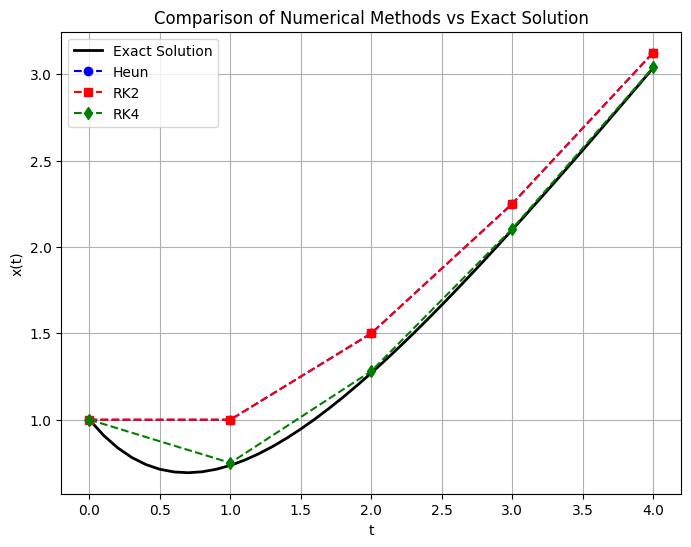

In [6]:
if __name__ == "__main__":
    a = 0
    b = 4
    x0 = 1
    h = 1

    # คำนวณด้วยแต่ละวิธี
    t_heun, x_heun = heun_method(f, a, b, x0, h)
    t_rk2, x_rk2 = rk2_method(f, a, b, x0, h)
    t_rk4, x_rk4 = rk4_method(f, a, b, x0, h)

    # ค่าจริง
    exact_vals = [exact_solution(t) for t in t_heun]

    # สร้าง DataFrame สำหรับตาราง
    df = pd.DataFrame({
        't': t_heun,
        'Exact': exact_vals,
        'Heun': x_heun,
        'Error_Heun': [abs(e - a) for e, a in zip(exact_vals, x_heun)],
        'RK2': x_rk2,
        'Error_RK2': [abs(e - a) for e, a in zip(exact_vals, x_rk2)],
        'RK4': x_rk4,
        'Error_RK4': [abs(e - a) for e, a in zip(exact_vals, x_rk4)]
    })

    # แสดงตาราง
    print("\nตารางเปรียบเทียบผลลัพธ์:")
    print(df.to_string(index=False, float_format="%.6f"))

    # ----------------- วาดกราฟ -----------------
    plt.figure(figsize=(8,6))
    # เส้นค่าจริง
    t_fine = [i*0.1 for i in range(int(b*10)+1)]
    x_fine = [exact_solution(t) for t in t_fine]
    plt.plot(t_fine, x_fine, 'k-', label='Exact Solution', linewidth=2)

    # จุดจากวิธีเชิงตัวเลข
    plt.plot(t_heun, x_heun, 'o--', label='Heun', color='blue')
    plt.plot(t_rk2, x_rk2, 's--', label='RK2', color='red')
    plt.plot(t_rk4, x_rk4, 'd--', label='RK4', color='green')

    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.title('Comparison of Numerical Methods vs Exact Solution')
    plt.legend()
    plt.grid(True)
    plt.show()